In [1]:
import yfinance as yf
import pandas as pd

#Fetch data
def fetch_market_data(start="2015-01-02", end = None):
    tickers = ["GC=F", "EURUSD=X"]
    df = yf.download(tickers, start=start, end=end, group_by="ticker")

    gold = df["GC=F"]["Close"]
    eurusd = df["EURUSD=X"]["Close"]

    data = pd.DataFrame({
        "Gold": gold,
        "EURUSD": eurusd
    })

    data = data.ffill()

    return data

In [2]:
data = fetch_market_data()
print(data.isnull().sum())
print(data.head(5))
print(data.shape)

[*********************100%***********************]  2 of 2 completed


Gold      0
EURUSD    0
dtype: int64
                   Gold    EURUSD
Date                             
2015-01-02  1186.000000  1.208941
2015-01-05  1203.900024  1.194643
2015-01-06  1219.300049  1.193902
2015-01-07  1210.599976  1.187536
2015-01-08  1208.400024  1.183600
(2939, 2)


In [3]:
data.describe()

,Gold,EURUSD
count,2939.000000,2939.000000
mean,1845.170328,1.121324
std,811.858173,0.052039
min,1050.800049,0.959619
25%,1273.899963,1.085517
50%,1721.500000,1.118981
75%,1957.250000,1.162743
max,5318.399902,1.251001


In [4]:
df = data.copy()
df['GC_pct_change']=df['Gold'].pct_change()*100
df['EURUSD_pct_change']=df['EURUSD'].pct_change()*100

In [66]:
import matplotlib.pyplot as plt
def plot_pct_change(data, events = None):
    df[['GC_pct_change','EURUSD_pct_change']].plot(figsize=(12,6),title = 'Daily % Change with Global Events')
    
    if events:
        for event in events:
            dt = pd.to_datetime(event['date'])
            plt.axvline(dt, color = 'red', linestyle ='--',alpha=0.7)
            plt.annotate(event['label'],
                 xy=(dt, plt.ylim()[1]),
                 xytext=(dt, plt.ylim()[1]*0.6),
                 fontsize=8, rotation=50)
            
    plt.show()

In [67]:
events = pd.read_csv("events.csv").to_dict('records')

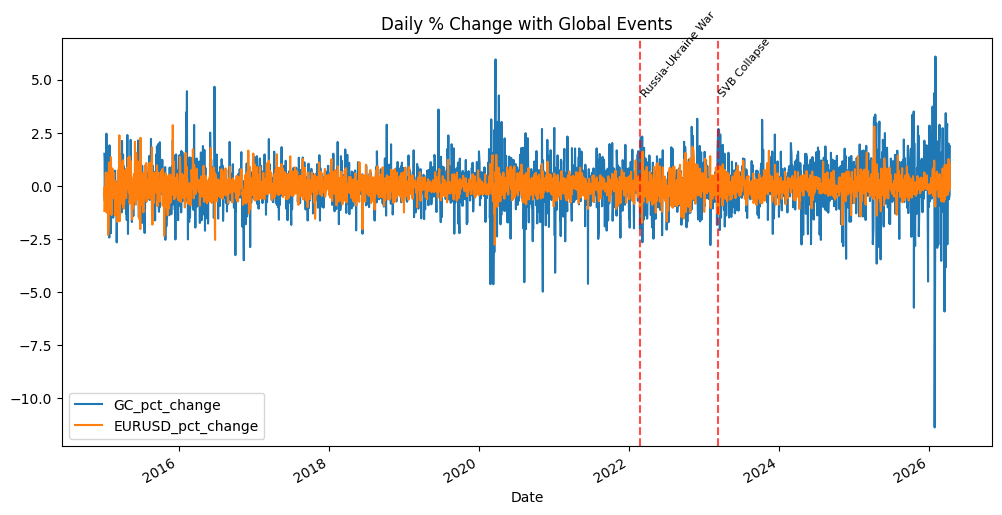

In [68]:
plot_pct_change(data,events)

In [8]:
flight_days = df[(df['GC_pct_change'] > 0) & (df['EURUSD_pct_change'] < 0)]
def detect_flight_to_safety(df):
    result = {
        "flight_days": flight_days.shape[0],
        "percentage":round((flight_days.shape[0]/ len(df)) * 100, 2),
        "data": flight_days
    }
    return result

In [9]:
result = detect_flight_to_safety(df)
print("Number of flight to safety days", result["flight_days"])
print("Percentage:", result["percentage"],"%")
result["data"][['GC_pct_change', 'EURUSD_pct_change']].sample(5)

Number of flight to safety days 752
Percentage: 25.59 %


,GC_pct_change,EURUSD_pct_change
Date,,
2021-11-11,0.844337,-0.945292
2021-04-16,0.770362,-0.119716
2015-01-09,0.628929,-0.337374
2024-12-10,1.227070,-0.097101
2016-06-27,0.189394,-2.543787


In [10]:
flight_days.loc[:,"year"]=flight_days.index.year
flight_days["year"].value_counts().sort_index()

year
2015    54
2016    61
2017    72
2018    54
2019    68
2020    65
2021    65
2022    73
2023    53
2024    83
2025    82
2026    22
Name: count, dtype: int64

2022-02-24: found
2023-03-10: not found in flight_days


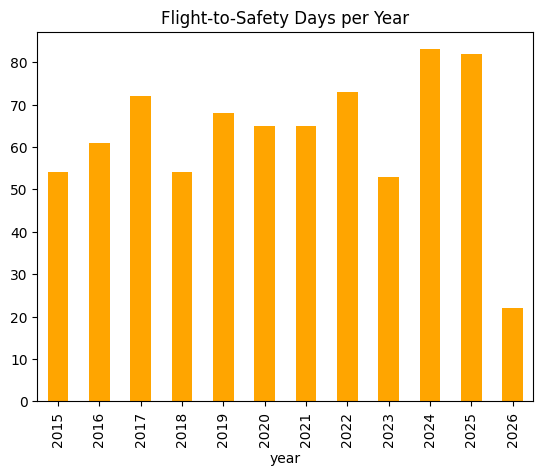

In [11]:
flight_days['year'].value_counts().sort_index().plot(kind='bar',title='Flight-to-Safety Days per Year', color='orange')
for event in events:
    if event['date'] in flight_days.index:
        print(f"{event['date']}: found")
    else:
        print(f"{event['date']}: not found in flight_days")


### Flight-to-Safety Analysis Summary

This chart shows the number of "Flight-to-Safety" days per year — when Gold prices rose while EUR/USD fell.

- In **2022**, heightened geopolitical uncertainty (e.g., Ukraine invasion in February) triggered frequent capital flows into gold.
- In **2023**, fewer such days were observed, despite events like the SVB collapse in March, suggesting a relatively calmer macroeconomic environment.
- In **2024**, there's a clear increase again, possibly due to inflation fears, rate changes, or geopolitical tensions.

This supports the theory that gold serves as a haven asset in periods of global stress.
